# Logiatic Regression with multiple classes

In [11]:
# Run a one-vs-rest strategy (with the iris dataset)

from sklearn.datasets import load_iris
iris = load_iris()

X = iris.data[:, [2, 3]]
y = iris.target

# create LinearRegression models for each class
from sklearn.linear_model import LogisticRegression
log_0 = LogisticRegression()
log_0.fit(X, y==0)
log_1 = LogisticRegression()
log_1.fit(X, y==1)
log_2 = LogisticRegression()
log_2.fit(X, y==2)

# Compare the raw model outputs
print(log_0.decision_function(X)[0])
print(log_1.decision_function(X)[0])
print(log_2.decision_function(X)[0])

# The maximum value is the model most confident to predicted the correct class

3.9862160747959736
-1.2846189933616459
-13.182331245547466


In [12]:
# Use a single model to predict the class

lr = LogisticRegression(multi_class='ovr')
lr.fit(X, y)

print(lr.predict(X)[0])

0


## Different loss functions to solve the multi-class problem

**One-vs-rest** - fit binaray models for each class

**Multinomial loss**/**softmax** - fit single multi-class model

> Note: In neuro network, 'multinominal' is widley used

In [13]:
# Run a 'softmax' strategy (with the iris dataset)

lr = LogisticRegression(multi_class='multinomial')
lr.fit(X, y)

print(lr.predict(X)[0])

0


In [14]:
# Train a binary classifier for the first class
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y==1, random_state=0)

svm_class_1 = SVC()
svm_class_1.fit(X_train, y_train==1)

SVC()

In [15]:
# Create/plot the binary classifier (class 1 vs. rest)
# Beware (don't share): Taken from the campus.datacampe course
# Prepare the helper functions
import matplotlib.pyplot as plt
import numpy as np

# Create a cool plot of the probabilities
def make_meshgrid(x, y, h=.02, lims=None):
    """Create a mesh of points to plot in

    Parameters
    ----------
    x: data to base x-axis meshgrid on
    y: data to base y-axis meshgrid on
    h: stepsize for meshgrid, optional

    Returns
    -------
    xx, yy : ndarray
    """

    if lims is None:
        x_min, x_max = x.min() - 1, x.max() + 1
        y_min, y_max = y.min() - 1, y.max() + 1
    else:
        x_min, x_max, y_min, y_max = lims
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, proba=False, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    ax: matplotlib axes object
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    if proba:
        Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,-1]
        Z = Z.reshape(xx.shape)
        out = ax.imshow(Z,extent=(np.min(xx), np.max(xx), np.min(yy), np.max(yy)), origin='lower', vmin=0, vmax=1, **params)
        ax.contour(xx, yy, Z, levels=[0.5])
    else:
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        out = ax.contourf(xx, yy, Z, **params)
    return out

def plot_classifier(X, y, clf, ax=None, ticks=False, proba=False, lims=None): # assumes classifier "clf" is already fit
    X0, X1 = X[:, 0], X[:, 1]
    xx, yy = make_meshgrid(X0, X1, lims=lims)

    if ax is None:
        plt.figure()
        ax = plt.gca()
        show = True
    else:
        show = False

    # can abstract some of this into a higher-level function for learners to call
    cs = plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8, proba=proba)
    if proba:
        cbar = plt.colorbar(cs)
        cbar.ax.set_ylabel('probability of red $\Delta$ class', fontsize=20, rotation=270, labelpad=30)
        cbar.ax.tick_params(labelsize=14)
    #ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=30, edgecolors='k', linewidth=1)
    labels = np.unique(y)
    if len(labels) == 2:
        ax.scatter(X0[y==labels[0]], X1[y==labels[0]], cmap=plt.cm.coolwarm, s=60, c='b', marker='o', edgecolors='k')
        ax.scatter(X0[y==labels[1]], X1[y==labels[1]], cmap=plt.cm.coolwarm, s=60, c='r', marker='^', edgecolors='k')
    else:
        ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=50, edgecolors='k', linewidth=1)

    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
#     ax.set_xlabel(data.feature_names[0])
#     ax.set_ylabel(data.feature_names[1])
    if ticks:
        ax.set_xticks(())
        ax.set_yticks(())
#     ax.set_title(title)
    if show:
        plt.show()
    else:
        return ax

/var/folders/xj/_rnfxgcx0j99crfb0488198w0000gn/T/ipykernel_75103/654641484.py:73: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X0[y==labels[0]], X1[y==labels[0]], cmap=plt.cm.coolwarm, s=60, c='b', marker='o', edgecolors='k')
/var/folders/xj/_rnfxgcx0j99crfb0488198w0000gn/T/ipykernel_75103/654641484.py:74: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X0[y==labels[1]], X1[y==labels[1]], cmap=plt.cm.coolwarm, s=60, c='r', marker='^', edgecolors='k')


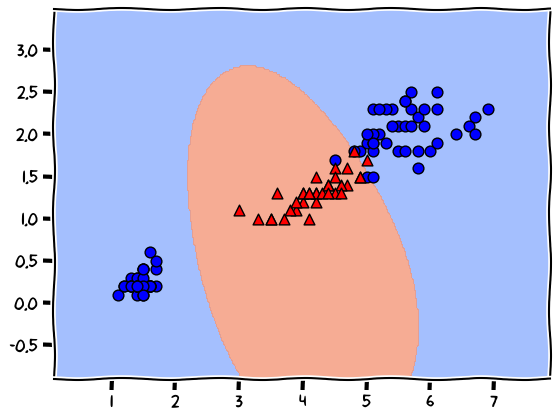

In [18]:
plt.xkcd()

plot_classifier(X_train, y_train==1, svm_class_1)